In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns
import os
from datetime import datetime
from pathlib import Path
from apify_client import ApifyClient
from dotenv import load_dotenv


df = pd.read_csv(r'D:\Steam_top1000\Data\steam_games_2026.csv')


In [2]:
df.head()
df.info()
print(df.shape)


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   AppID              1000 non-null   int64  
 1   Name               1000 non-null   str    
 2   Release_Date       999 non-null    str    
 3   Primary_Genre      1000 non-null   str    
 4   All_Tags           986 non-null    str    
 5   Price_USD          1000 non-null   float64
 6   Discount_Pct       1000 non-null   int64  
 7   Review_Score_Pct   1000 non-null   int64  
 8   Total_Reviews      1000 non-null   int64  
 9   Steam_Deck_Status  1000 non-null   str    
 10  Estimated_Owners   1000 non-null   int64  
 11  24h_Peak_Players   1000 non-null   int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 93.9 KB
(1000, 12)


In [3]:
df_val = df['Name'].value_counts
df_des = df['Price_USD'].describe

print(df_val)
print(df_des)

<bound method IndexOpsMixin.value_counts of 0                      Counter-Strike 2
1                      Slay the Spire 2
2                        Crimson Desert
3                              Marathon
4                 Resident Evil Requiem
                     ...               
995                         Paleo Pines
996              MARVEL Cosmic Invasion
997    Door Kickers 2: Task Force North
998                        Labyrinthine
999                              Vellum
Name: Name, Length: 1000, dtype: str>
<bound method NDFrame.describe of 0       0.00
1      24.99
2      69.99
3      39.99
4      69.99
       ...  
995     7.49
996    29.99
997    24.99
998     9.99
999    11.99
Name: Price_USD, Length: 1000, dtype: float64>


In [4]:
df.loc[2, ['Name', 'Price_USD']]


Name         Crimson Desert
Price_USD             69.99
Name: 2, dtype: object

In [5]:
df.iloc[0:3, 0:5]

,AppID,Name,Release_Date,Primary_Genre,All_Tags
0,730,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...
1,2868840,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...
2,3321460,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...


In [6]:
df.sort_values(by= 'Name')

,AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
787,3768760,007 First Light,2026-05-27,Action,Singleplayer;Action;Adventure;Action-Adventure...,69.99,0,0,0,Unknown,0,0
893,1895900,1348 Ex Voto,2026-03-12,Action,Singleplayer;Third Person;Medieval;Action-Adve...,22.49,10,51,417,Unknown,12510,0
210,251570,7 Days to Die,2024-07-25,Action,Survival;Zombies;Multiplayer;Open World;Open W...,44.99,0,85,270508,Unknown,8115240,17045
851,1629520,A Little to the Left,2022-11-08,Casual,Puzzle;Relaxing;Cute;Casual;Singleplayer;Point...,14.99,0,93,15287,Unknown,458610,422
374,1222700,A Way Out,2020-06-18,Action,Online Co-Op;Co-op;Split Screen;Story Rich;Loc...,2.99,90,88,72109,Unknown,2163270,262
...,...,...,...,...,...,...,...,...,...,...,...,...
525,3226450,iRacing Arcade,2026-03-03,Racing,Racing;Arcade;Driving;Automobile Sim;Managemen...,24.99,0,72,695,Unknown,20850,0
207,2456740,inZOI,2025-03-27,Adventure,Life Sim;Character Customization;Simulation;Re...,39.99,0,74,26794,Unknown,803820,1039
926,590830,s&box,April 2026,Action,Sandbox;Casual;Game Development;Building;Level...,0.00,0,0,0,Unknown,0,0
231,3354750,skate.,2025-09-16,Action,Multiplayer;Skateboarding;Action;Free to Play;...,0.00,0,50,266,Unknown,7980,0


In [7]:
df.dtypes


AppID                  int64
Name                     str
Release_Date             str
Primary_Genre            str
All_Tags                 str
Price_USD            float64
Discount_Pct           int64
Review_Score_Pct       int64
Total_Reviews          int64
Steam_Deck_Status        str
Estimated_Owners       int64
24h_Peak_Players       int64
dtype: object

In [8]:
df.isna()

,AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull()

,AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

Question= Are games loosing out on sales do to poor optimization for older/weaker hardware?

In [11]:
df.groupby('Name')['Total_Reviews'].mean().sort_values(ascending=False)

Name
Counter-Strike 2                  4980365.0
PUBG: BATTLEGROUNDS               1757549.0
Tom Clancy's Rainbow Six Siege    1234092.0
Terraria                          1201073.0
Rust                              1116689.0
                                    ...    
Old School RuneScape                    0.0
Out of the Park Baseball 27             0.0
Once Human                              0.0
s&box                                   0.0
007 First Light                         0.0
Name: Total_Reviews, Length: 1000, dtype: float64

In [12]:
df.groupby('Name')['24h_Peak_Players'].mean().sort_values(ascending=False)

Name
Counter-Strike 2           1013936.0
Dota 2                      623941.0
PUBG: BATTLEGROUNDS         314682.0
ELDEN RING NIGHTREIGN       163599.0
Rust                        143870.0
                             ...    
AETHUS                           0.0
Where Winds Meet                 0.0
Umamusume: Pretty Derby          0.0
WWE 2K26                         0.0
Alchemy Factory                  0.0
Name: 24h_Peak_Players, Length: 1000, dtype: float64

In [13]:
df.head()

,AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,730,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0.00,0,83,4980365,Unknown,149410950,1013936
1,2868840,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,24.99,0,97,49549,Unknown,1486470,0
2,3321460,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,69.99,0,0,0,Unknown,0,0
3,3065800,Marathon,2026-03-05,Action,Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...,39.99,0,90,24360,Unknown,730800,0
4,3764200,Resident Evil Requiem,2026-02-26,Action,Survival Horror;Zombies;Horror;Third-Person Sh...,69.99,0,96,79667,Unknown,2390010,0


In [14]:
df.dtypes

AppID                  int64
Name                     str
Release_Date             str
Primary_Genre            str
All_Tags                 str
Price_USD            float64
Discount_Pct           int64
Review_Score_Pct       int64
Total_Reviews          int64
Steam_Deck_Status        str
Estimated_Owners       int64
24h_Peak_Players       int64
dtype: object

In [15]:
df = df.drop(columns=['Steam_Deck_Status','AppID'])

df.head()

,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0.00,0,83,4980365,149410950,1013936
1,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,24.99,0,97,49549,1486470,0
2,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,69.99,0,0,0,0,0
3,Marathon,2026-03-05,Action,Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...,39.99,0,90,24360,730800,0
4,Resident Evil Requiem,2026-02-26,Action,Survival Horror;Zombies;Horror;Third-Person Sh...,69.99,0,96,79667,2390010,0


In [16]:
df.describe()


,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,21.992930,18.145000,79.658000,6.387119e+04,1.916136e+06,5.213243e+03
std,18.812135,28.613716,19.382227,2.115879e+05,6.347638e+06,4.037537e+04
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.790000,0.000000,75.000000,1.638250e+03,4.914750e+04,0.000000e+00
50%,19.790000,0.000000,85.000000,1.173200e+04,3.519600e+05,2.865000e+02
75%,29.990000,35.000000,92.000000,4.851575e+04,1.455472e+06,1.601000e+03
max,69.990000,95.000000,100.000000,4.980365e+06,1.494110e+08,1.013936e+06


In [17]:
df_zero_count = (df == 0).sum()
df_zero_count


Name                  0
Release_Date          0
Primary_Genre         0
All_Tags              0
Price_USD           108
Discount_Pct        658
Review_Score_Pct     31
Total_Reviews       102
Estimated_Owners    102
24h_Peak_Players    304
dtype: int64

In [18]:
df = df.drop('Discount_Pct', axis= 1)

df

,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0.00,83,4980365,149410950,1013936
1,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,24.99,97,49549,1486470,0
2,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,69.99,0,0,0,0
3,Marathon,2026-03-05,Action,Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...,39.99,90,24360,730800,0
4,Resident Evil Requiem,2026-02-26,Action,Survival Horror;Zombies;Horror;Third-Person Sh...,69.99,96,79667,2390010,0
...,...,...,...,...,...,...,...,...,...
995,Paleo Pines,2023-09-26,Adventure,Dinosaurs;Farming Sim;Exploration;Relaxing;Ind...,7.49,93,1921,57630,50
996,MARVEL Cosmic Invasion,2025-12-01,Action,Beat 'em up;Arcade;Pixel Graphics;Superhero;Co...,29.99,90,1630,48900,0
997,Door Kickers 2: Task Force North,2025-02-10,Action,Tactical;Top-Down;Real Time Tactics;Real-Time ...,24.99,96,11539,346170,505
998,Labyrinthine,2023-08-18,Action,Horror;Online Co-Op;Co-op;Puzzle;Psychological...,9.99,70,13549,406470,179


Do Steam Users tend to play less expensive games over more expensive? 

In [19]:
pd.set_option('display.float_format', '{:,.0f}'.format)
df_grp_pr_own = df.groupby('Price_USD')['Estimated_Owners'].mean()


df_grp_pr_own

Price_USD
0    2,567,829
0            0
1            0
1            0
1       36,651
        ...   
45   2,738,025
49     193,770
50   1,983,931
60   3,915,769
70     921,367
Name: Estimated_Owners, Length: 99, dtype: float64

In [20]:
df_grp_pr_o = df.groupby('Price_USD')['Estimated_Owners'].mean().max()

df_grp_pr_o

np.float64(5657010.0)

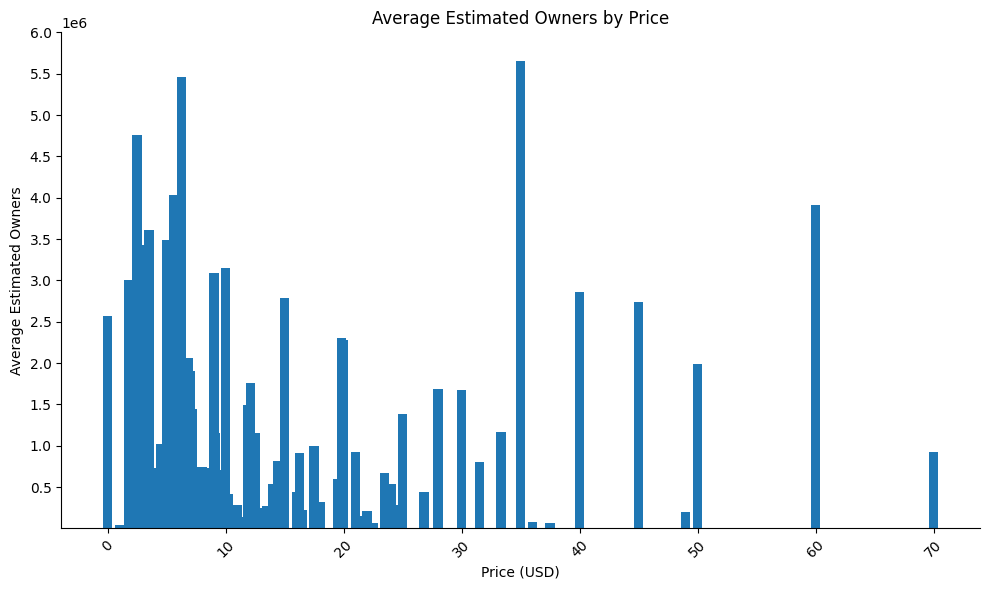

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(
    df_grp_pr_own.index,
    df_grp_pr_own.values,

)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.xlabel("Price (USD)")
plt.ylabel("Average Estimated Owners")
plt.title("Average Estimated Owners by Price")

plt.xticks(rotation=45)
plt.yticks(
    [
        500000,
        1000000,
        1500000, 
        2000000, 
        2500000, 
        3000000, 
        3500000, 
        4000000, 
        4500000, 
        5000000, 
        5500000, 
        6000000
    ]
)
plt.tight_layout()
plt.show()

Surprisingly games that are free or less than $20.00 USD are not the most owned. It seems games targeted between $30.00 USD to $40.00 USD see the most sales, although the $0.00 USD to $ $10.00 USD range is right behind it in Estimated owners. Could this be why many new games target the $30.00 USD to $40.00 USD range? (Need to compare release date by estimated owners and price)

What games are most players getting based on price? 

In [22]:
df.head()

,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0,83,4980365,149410950,1013936
1,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,25,97,49549,1486470,0
2,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,70,0,0,0,0
3,Marathon,2026-03-05,Action,Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...,40,90,24360,730800,0
4,Resident Evil Requiem,2026-02-26,Action,Survival Horror;Zombies;Horror;Third-Person Sh...,70,96,79667,2390010,0


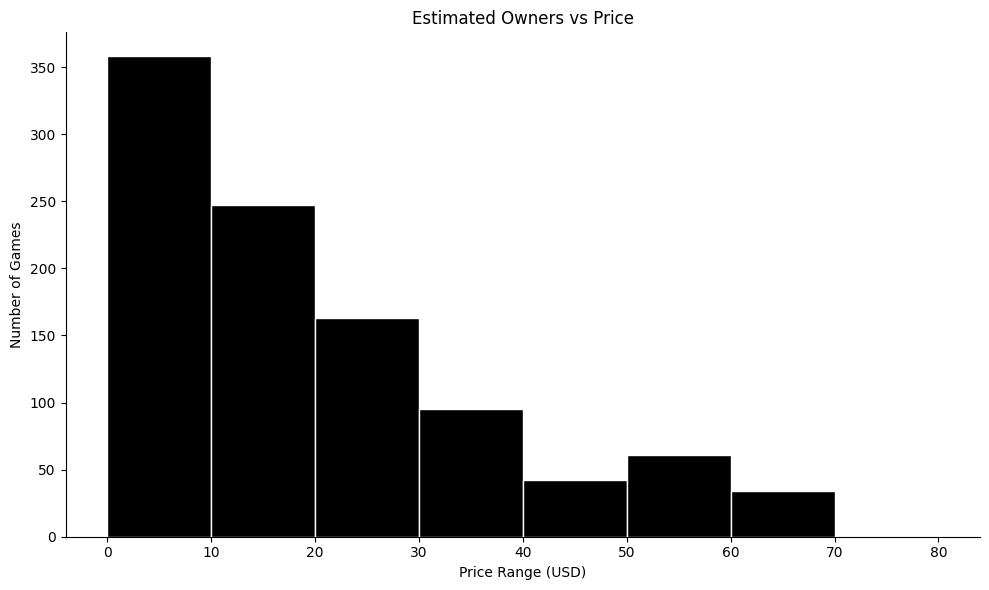

In [23]:
plt.figure(figsize=(10,6))

plt.hist(
    df['Price_USD'],
    bins=[0,10,20,30,40,50,60,70,80],
    edgecolor='white',
    color= "black"
)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Price Range (USD)")
plt.ylabel("Number of Games")
plt.title("Estimated Owners vs Price")

plt.xticks([0,10,20,30,40,50,60,70,80])

plt.tight_layout()
plt.show()

Unsurprisingly, the majority of games in the top 1,000 are less then $20, with the most owned being between $0.00 USD to $10.00 USD

After the Data Ethics lesson and some thnking of how to actually answer my original question, "Are games loosing out on sales do to poor optimization for older/weaker hardware?", I decided that a t this time I was unable to find the data to effectivily ask that question. While I had originally tried to scrape steam hardware survey, I found that there was no connections I could use to reliably join the data much less answer a proper question. I now have decided to see: "Which tags are being played the most?"
I plan on getting an api to update the data set/ or to create a way to update with a new csv file each month so you could see current trends and previous. 

In [24]:
df.head()

,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0,83,4980365,149410950,1013936
1,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,25,97,49549,1486470,0
2,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,70,0,0,0,0
3,Marathon,2026-03-05,Action,Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...,40,90,24360,730800,0
4,Resident Evil Requiem,2026-02-26,Action,Survival Horror;Zombies;Horror;Third-Person Sh...,70,96,79667,2390010,0


In [25]:
df["All_Tags"] = df["All_Tags"].str.split(";")
tags_df = df.explode("All_Tags")
tags_df["All_Tags"] = tags_df["All_Tags"].str.strip()
tags_df = tags_df[tags_df["All_Tags"] != ""]
tag_24_peak = (tags_df.groupby("All_Tags")["24h_Peak_Players"].sum().sort_values(ascending=False).head(20).sort_values())

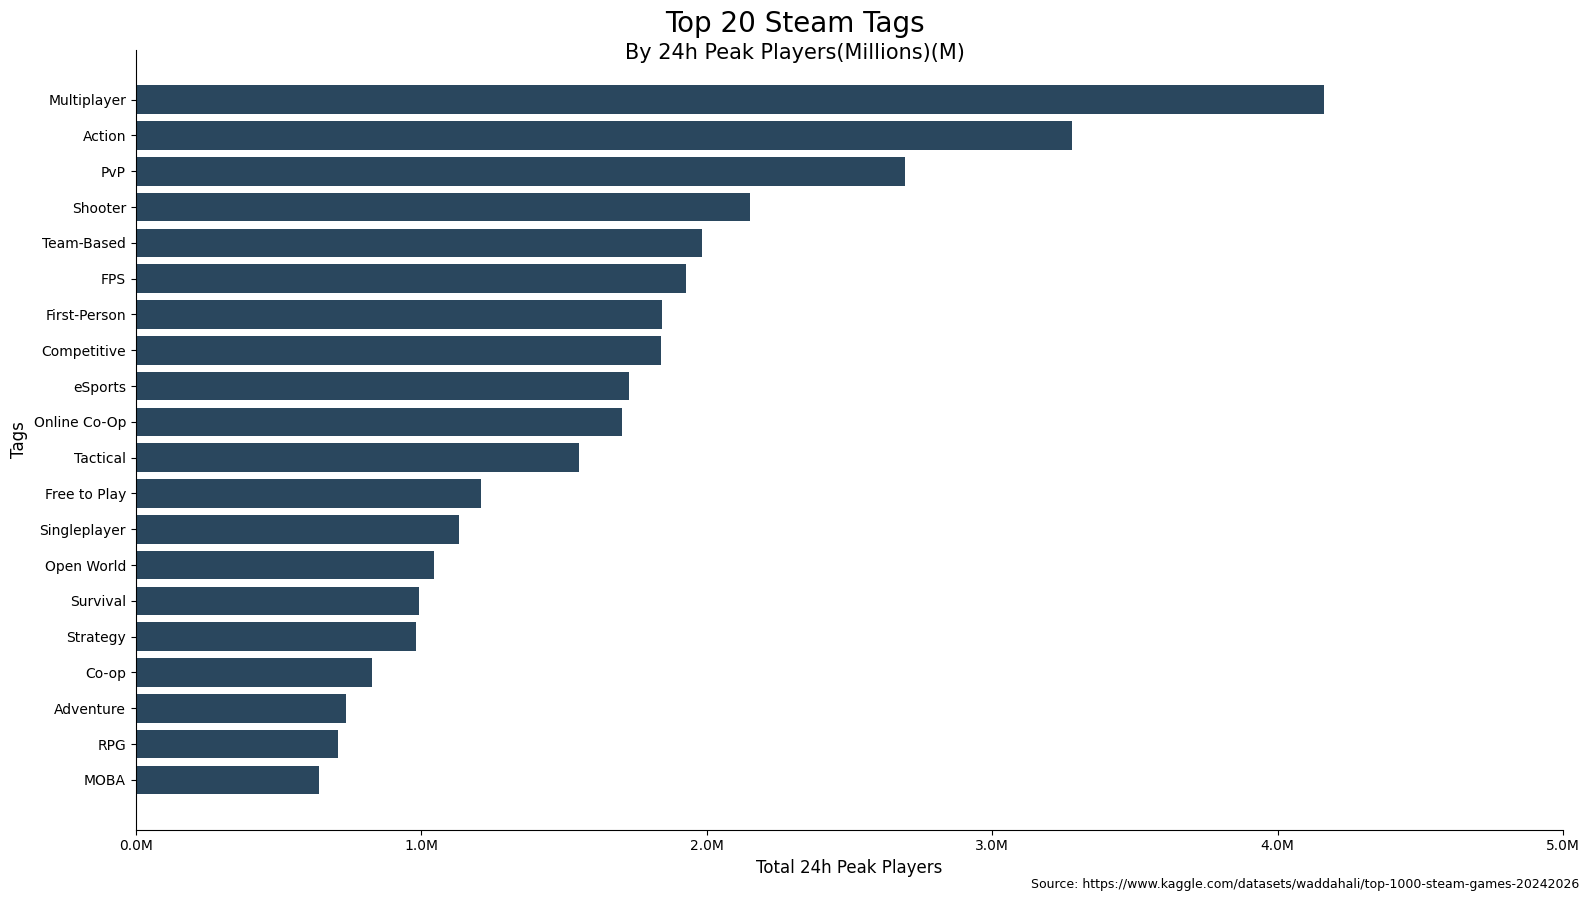

In [26]:
fig, ax= plt.subplots(figsize=(16,9))

ax.barh(tag_24_peak.index,tag_24_peak.values, color="#2a475e")

fig.suptitle("Top 20 Steam Tags", fontsize=20, y=0.98, ha="center",color="#000000")
fig.text(0.5,0.925, "By 24h Peak Players(Millions)(M)", ha="center",fontsize=15,color="#000000")
ax.set_xlabel("Total 24h Peak Players", fontsize=12, color="#000000")
ax.set_ylabel("Tags", fontsize=12,color="#000000")
fig.text(0.99, 0.001,
        "Source: https://www.kaggle.com/datasets/waddahali/top-1000-steam-games-20242026",
        ha="right",va="bottom",fontsize=9, color="#000000")

ax.set_xlim(0,5000000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M"))


fig.tight_layout()
plt.show()

From this bar graph I noticed that through out the top 1000 games on steam  the current most played tag is multiplayer. This lets us know that most people rather play games together or against other live players. I think I may develop this to "Do multiplayer games sell more than single player games?". I had set this to a horizontal bar chart because I was comparing different catagories and their vaules, I then realized a normal bar chart may be hard to read as some of the tags where long and I did not want to resort to rotatting them. I find the horizontal representation more visually appeasing when doing comparison with many tags, genres and titles. I wanted to keep the color choice neutral so for text I went with black and for the bar graph itslef I used "#2a475e" which from "https://colorswall.com/palette/193" is from steams own color pallette.I am still debating on if the "Tags" lable on the y axis could be changed visually as I feel it may be a bit close to the ticks though its not hard to read either. I swapped the acsending order to False to have the highest peak player count on top of the chart so it's naturally one of the first things you see. To ensure acuracy, I first took the All_Tags column and split the strings up by ";" as each row in the column looked like this: FPS;Shooter;Multiplayer;Competitive;Action;Team-Based;eSports;Tactical;First-Person;PvP. Once I had them split up I used .explode() to count each instance of the tag i.e. multiplayer, RPG, and Survival. I then cleaned up all the strings in the new "All_Tags" column, i got rid of any extra spaces and any empty strings. Once I had the data clean I did a .groupby() showing just the top 20 (there where many tags and the plot looked overly crowed and I assumed the top 20 would be realativly insightfull for my question.) I compared the tags by peak player numbers over the last 24 hours(given this data is just a snapshot and not fully up to date at exact time, however if I can find an API to only update the 24h_Peak_Players column I would like to implement that.). If I do manage that and updating the tags each month with another API then it would be even more acurate. 




In [27]:
df.head()

,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0,Counter-Strike 2,2012-08-21,Action,"[FPS, Shooter, Multiplayer, Competitive, Actio...",0,83,4980365,149410950,1013936
1,Slay the Spire 2,2026-03-05,Indie,"[Strategy, Roguelike, Card Game, Deckbuilding,...",25,97,49549,1486470,0
2,Crimson Desert,2026-03-19,Action,"[Action, Open World, Singleplayer, Adventure, ...",70,0,0,0,0
3,Marathon,2026-03-05,Action,"[Extraction Shooter, PvP, Multiplayer, Sci-fi,...",40,90,24360,730800,0
4,Resident Evil Requiem,2026-02-26,Action,"[Survival Horror, Zombies, Horror, Third-Perso...",70,96,79667,2390010,0


In [28]:
df["Multiplayer"] = df["All_Tags"].str.contains("Multiplayer", case=False, na=False)

df["Multiplayer"].head()

0    False
1    False
2    False
3    False
4    False
Name: Multiplayer, dtype: bool

In [29]:
df["Singleplayer"] = df["All_Tags"].str.contains("Singleplayer",case=False,na=False)

df["Singleplayer"].head()

0    False
1    False
2    False
3    False
4    False
Name: Singleplayer, dtype: bool

I wanted to check multiplayer vs single player to see which catagory of game has more sales. I wanted to create two new columns so I could itterate over each and then compare via ownership. I want to list all games that are either multiplayer, singleplayer, both and neither. 

In [30]:
def game_type(row):
    if row["Multiplayer"] and row["Singleplayer"]:
        return "Both"
    elif row["Multiplayer"]:
        return "Multiplayer"
    elif row["Singleplayer"]:
        return "Singleplayer"
    else:
        return "Other"

df["Game_Type"] = df.apply(game_type, axis=1)

df["Game_Type"].head()

0    Other
1    Other
2    Other
3    Other
4    Other
Name: Game_Type, dtype: str

I created a function to itterate over the two new columns, Multiplayer and Singleplayer, and output wether it was a multiplayer game, a singleplayer game, both singleplayer and multiplayer and other to list all other games that did not have those two tags.

In [31]:
grouped_games = df.groupby("Game_Type")["Estimated_Owners"].apply(list)

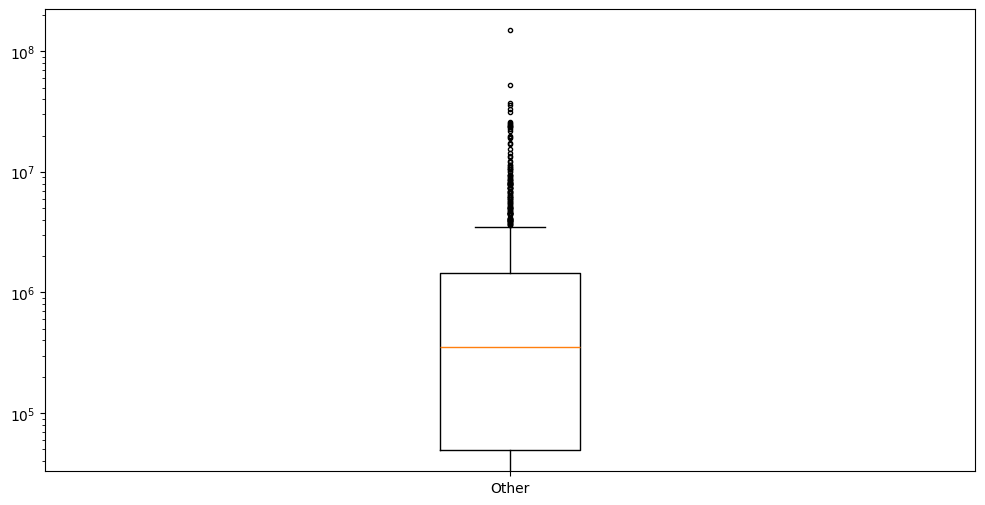

In [32]:
fig, ax = plt.subplots(figsize=(12,6))

ax.boxplot(grouped_games.values, flierprops=dict(marker='o', markersize=3))
ax.set_xticklabels(grouped_games.index)
ax.set_yscale("log")

plt.show()

Just to get a quick visual, I created a boxplot. From this I noticed that there where a lot of outliers in the data, this told me that some games just did extremly well for their genre. I looked online to see if there would be a better way to repreesent this data and found that a violin plot would be better for my situation as I wanted to show full distruibution of ownership rather than just averages. 

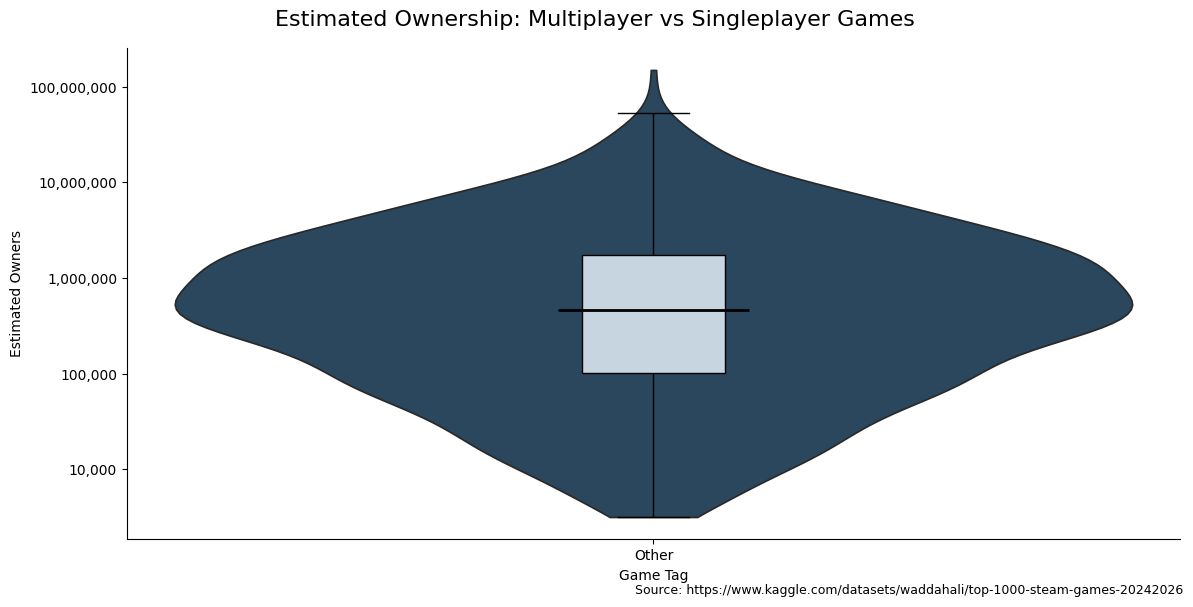

In [33]:
# Create a copy of the dataframe so the original data remains unchanged
df_vplot = df.copy()

# Remove games with zero or negative ownership values
# Logarithmic transformations cannot handle values <= 0
df_vplot = df_vplot[df_vplot["Estimated_Owners"] > 0]

# Apply a base-10 logarithmic transformation to compress extreme ownership ranges
df_vplot["log_owners"] = np.log10(df_vplot["Estimated_Owners"])

# Group by game type, calculate median ownership,
# sort categories from highest to lowest median ownership,
# and store the ordered category labels
vplot_ordered = (
    df_vplot
    .groupby("Game_Type")["Estimated_Owners"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Define custom colors for each category
# Bright blue highlights the primary comparison categories
# Dark muted colors provide contextual categories
palette = {
    "Multiplayer": "#66c0f4",
    "Singleplayer": "#66c0f4",
    "Both": "#2a475e",
    "Other": "#2a475e"
}

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Create violin plot to show full ownership distribution
sns.violinplot(
    data=df_vplot,
    x="Game_Type",          # Categories on x-axis
    y="log_owners",         # Log-transformed ownership values
    hue="Game_Type",        # Apply colors by category
    order=vplot_ordered,    # Use custom category order
    palette=palette,        # Apply custom colors
    saturation=1,           # Use full color intensity
    cut=0,                  # Prevent violins from extending beyond actual data
    inner=None,             # Remove internal violin markings
    legend=False,           # Remove redundant legend
    ax=ax
)

# Overlay boxplots for statistical summaries
sns.boxplot(
    data=df_vplot,
    x="Game_Type",
    y="log_owners",
    order=vplot_ordered,
    width=0.12,             # Narrow boxplots so violins remain visible
    showfliers=False,       # Hide outlier points to reduce clutter

    # Customize box appearance
    boxprops={
        "facecolor": "#c7d5e0",
        "edgecolor": "black",
        "zorder": 3         # Draw boxplot above violin layer
    },

    # Customize whiskers and caps
    whiskerprops={"color": "black"},
    capprops={"color": "black"},

    # Define outlier styling if enabled
    flierprops={
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 4
    },

    ax=ax
)

# Calculate median ownership for each category
medians = df_vplot.groupby("Game_Type")["log_owners"].median()

# Manually draw thicker median lines for better visibility
for i, game_type in enumerate(vplot_ordered):

    ax.hlines(
        medians[game_type], # Median y-value
        i - 0.08,           # Left x-position
        i + 0.08,           # Right x-position
        color="black",
        linewidth=2,
        zorder=20           # Draw above all other plot layers
    )

# Convert logarithmic y-axis values back into readable ownership numbers
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda y, _: f"{int(10**y):,}"
    )
)

# Remove top and right plot borders for cleaner appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add chart title
fig.suptitle(
    "Estimated Ownership: Multiplayer vs Singleplayer Games",
    ha="center",
    fontsize=16
)

# Add axis labels
ax.set_ylabel("Estimated Owners")
ax.set_xlabel("Game Tag")

# Add source citation
fig.text(
    0.99,
    0.001,
    "Source: https://www.kaggle.com/datasets/waddahali/top-1000-steam-games-20242026",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#000000"
)

# Automatically adjust layout spacing
fig.tight_layout()

# Display the final visualization
plt.show()

Once I knew I wanted to show distributions instead of averages, as you know Steam is an abundent place to find all sorts of games and I knew the data could be very skewed on ownership. I added a boxplot overlay to help show that while multiplayer and singleplayer games are faily close in median estimated ownership  With this violin plot I can tell that most games for singleplayer and multiplayer fall around the median ownership range though, multiplayer games have a wider spread and more extreme low to high values. If a developer was to release a game with multiplayer it seems they have greater risk but also a greater reward if it is successfull. I stuck with the same color pallette from:
"https://colorswall.com/palette/193", that I used in my bar chart. I added the lighter blue to highlight the multiplayer and singleplayer catagories to draw more focus to them. I chose to compress the data with "np.log10(df_vplot["Estimated_Owners"])" as without it the data was highly skewed and was not showing on the vilolin chart properly/effectively.I order the data on median ownership rather than the mean because ownership data is highly skewed and contains large outliers. Due to the bar chart showing that multiplayer and singleplayer tags where in the most owned games, I focused attention there and decied to include a catagory for "both" and "other" to see if giving the ablity to play by yourself and with others was more favored then just one or the other and the "other" to show all tags as more of a bench mark outside of multiplayer and singleplayer. The keep everything accurate before I comressed the data, I filtered out any values less than 0 from Estimated Owners. I then changed the data using np.log10() before making the violin chart as to not cause errors in the distribution estimation. I then disabled the fliers as the violin chart already comunicates those outliers and this helps to keep the overall chart clean. 

In [37]:
#loading the .env file 
load_dotenv()

#Loads the Apify API token from the `apify_token` environment variable using `os.getenv()`.
apify_token = os.getenv("apify_token")

# Create an Apify client object
# This allows Python to communicate with the Apify platform
client = ApifyClient(apify_token)

# Get today's date and format it as YYYY-MM-DD
# This is used later for timestamped filenames
today = datetime.today().strftime("%Y-%m-%d")

# Define the folder where CSV files will be saved
output_dir = Path(r"D:\Steam_top1000\Data")

# Define the Actor input settings
run_input = {

    # Empty query means no keyword filtering
    "query": "",

    # Steam search URL for the Top Sellers page
    "steamSearchUrls": [
        "https://store.steampowered.com/search/?filter=topsellers"
    ],

    # Maximum number of games to retrieve
    "maxItems": 1000,

    # Use United States Steam store data
    "country": "US",

    # Return results in English
    "language": "english"
}

# Run the Apify Steam scraper Actor
run = client.actor(
    "lokki/steam-top-sellers-scraper"
).call(run_input=run_input)

# Retrieve all scraped dataset items from the completed Actor run
items = list(

    client.dataset(
        run["defaultDatasetId"]
    ).iterate_items()
)

# Convert the returned JSON data into a pandas DataFrame
df = pd.DataFrame(items)

# Print all dataframe column names
print(df.columns)

# Display the first few rows of the dataset
print(df.head())

# Create a timestamped filename
filename = output_dir / f"steam_top_sellers_{today}.csv"

# Export the dataframe to a CSV file

df.to_csv(filename, index=False)

# Print confirmation message showing where the file was saved
print(f"Saved {len(df)} rows to {filename}")

[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> Status: RUNNING, Message: 
[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> 2026-07-02T21:25:59.692Z ACTOR: Pulling container image of build ReAm1K9xi9OZPAt4S from registry.
[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> 2026-07-02T21:26:04.726Z ACTOR: Creating container.
[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> 2026-07-02T21:26:04.769Z ACTOR: Starting container.
[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> 2026-07-02T21:26:04.771Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> 2026-07-02T21:26:05.169Z
[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> 2026-07-02T21:26:05.171Z > steam-top-sellers-scraper@1.0.0 start
[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> 2026-07-02T21:26:05.172Z > node src/main.js
[apify.steam-top-sellers-scraper runId:3aTPjfpeijyrUyWum] -> 2026-07-02T21:26:05

Index(['rank', 'appId', 'title', 'url', 'releaseDate', 'priceText',
       'finalPriceCents', 'discountPercent', 'reviewSummary', 'reviewPercent',
       'reviewCount', 'platforms', 'imageUrl', 'scrapedAt', 'currentPlayers',
       'developer', 'publisher', 'genres', 'categories',
       'recommendationsTotal', 'metacriticScore', 'shortDescription', 'isFree',
       'type', 'demandScore', 'qualityScore', 'commercialScore',
       'momentumScore', 'opportunityScore', 'marketPosition',
       'opportunityType', 'pricingPosition', 'audienceSignal',
       'monetizationSignal', 'competitiveSignal', 'intelligenceTags',
       'riskFlags', 'insightSummary', 'recommendedAction'],
      dtype='str')
   rank    appId             title  \
0     1  4165910     Steam Machine   
1     2  2767030     Marvel Rivals   
2     3      730  Counter-Strike 2   
3     4  4704690  MECCHA CHAMELEON   
4     5   252490              Rust   

                                                 url   releaseDate  pr

I had found an api online that would provide me all of current information for the top 1000 steam games. The API I am using is Steam Market Intelligence: Top Sellers & Opportunity Tracker, from "lokki/steam-top-sellers-scraper". I had planned on going back through and changing column names and making sure the data sets where structured similarly, however with the api call making a new csv each time it is ran with a time stamp, I may choose to do away with the original csv to provide the most up-to-date modle. For my capstone I will be generating a few more snapshots of data and ploting that data to show the changes over time within the estimated ownership of multiplayer vs singleplayer games. Though I am still not sure all this API can do, if it cannot get past data snapshots I may find another api that can so I can show a more acurate reprsentation of the data, as I would only have data within this month or so.  

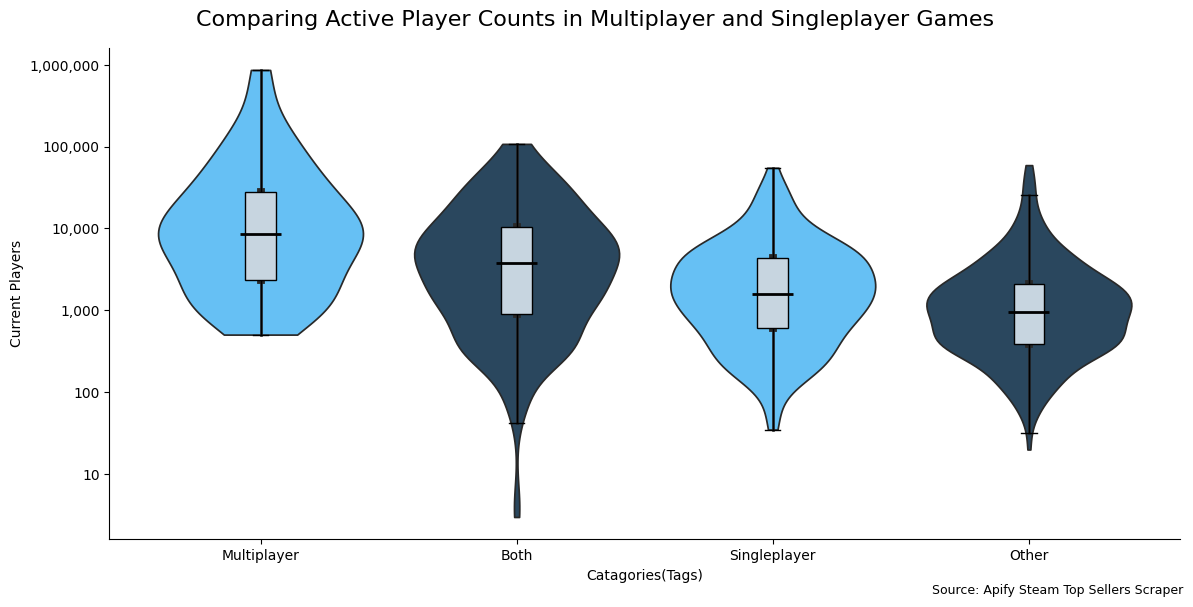

In [38]:
# Create a copy of the dataframe so the original dataset remains unchanged
df_vplot = df.copy()

# Define a custom function to classify games by gameplay type
def classify_game_type(categories):

    # Check if categories are stored as a list
    if isinstance(categories, list):

        # Convert all category values to lowercase strings
        cats = [str(c).lower() for c in categories]

    # Check if categories are stored as a string
    elif isinstance(categories, str):

        # Convert string to lowercase
        cats = categories.lower()

    # Handle missing or invalid category values
    else:
        return "Other"

    # Check whether multiplayer exists in the category data
    multiplayer = "multi-player" in cats

    # Check whether singleplayer exists in the category data
    singleplayer = "single-player" in cats

    # Assign category labels based on detected gameplay types
    if multiplayer and singleplayer:
        return "Both"

    elif multiplayer:
        return "Multiplayer"

    elif singleplayer:
        return "Singleplayer"

    else:
        return "Other"


# Apply the classification function to every row in the dataframe
# and create a new column called "Catagories"
df_vplot["Catagories"] = (
    df_vplot["categories"]
    .apply(classify_game_type)
)

# Remove games with zero or negative active-player counts
# Logarithmic transformations require positive values
df_vplot = df_vplot[df_vplot["currentPlayers"] > 0]

# Apply a base-10 logarithmic transformation to compress
# extremely large player-count differences
df_vplot["log_players"] = np.log10(
    df_vplot["currentPlayers"]
)

# Group games by category, calculate median current players,
# sort categories from highest to lowest median,
# and store the ordered category labels
vplot_ordered = (
    df_vplot
    .groupby("Catagories")["currentPlayers"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Define custom colors for each gameplay category
palette = {

    # Bright blue highlights the primary comparison categories
    "Multiplayer": "#66c0f4",
    "Singleplayer": "#66c0f4",

    # Dark muted colors provide contextual comparison groups
    "Both": "#2a475e",
    "Other": "#2a475e"
}

# Create the plotting figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Create violin plots showing the full distribution
# of active player counts
sns.violinplot(
    data=df_vplot,

    # Place gameplay categories on x-axis
    x="Catagories",

    # Use log-transformed player counts on y-axis
    y="log_players",

    # Apply colors based on gameplay category
    hue="Catagories",

    # Use categories sorted by median player count
    order=vplot_ordered,

    # Apply custom color palette
    palette=palette,

    # Use full color intensity
    saturation=1,

    # Prevent violins from extending beyond actual data
    cut=0,
)

# Overlay boxplots to display statistical summaries
sns.boxplot(
    data=df_vplot,
    x="Catagories",
    y="log_players",

    # Match violin category ordering
    order=vplot_ordered,

    # Keep boxplots narrow so violins remain visible
    width=0.12,

    # Hide outlier points to reduce clutter
    showfliers=False,

    # Customize box appearance
    boxprops={
        "facecolor": "#c7d5e0",
        "edgecolor": "black",

        # Draw boxplot above violin layer
        "zorder": 3
    },

    # Customize whisker and cap colors
    whiskerprops={"color": "black"},
    capprops={"color": "black"},

    ax=ax
)

# Calculate median values for each gameplay category
medians = (df_vplot.groupby("Catagories")["log_players"].median())

# Loop through each category and manually draw thicker median lines
# Without this no median lines show
for i, catagory in enumerate(vplot_ordered):

    ax.hlines(

        # Y-position of median line
        medians[catagory],

        # Left and right x-axis positions
        i - 0.08,
        i + 0.08,

        # Styling
        color="black",
        linewidth=2,

        # Draw above all plot layers
        zorder=20
    )

# Convert logarithmic y-axis values back into readable
# player-count labels
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(10**y):,}"))

# Remove unnecessary plot borders 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add chart title
fig.suptitle(
    "Comparing Active Player Counts in Multiplayer and Singleplayer Games",
    ha="center",
    fontsize=16
)

# Add axis labels
ax.set_ylabel("Current Players")
ax.set_xlabel("Catagories(Tags)")

# Add source citation
fig.text(
    0.99,
    0.001,
    "Source: Apify Steam Top Sellers Scraper",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#000000"
)

# Automatically adjust spacing to prevent overlap
fig.tight_layout()

# Display the completed visualization
plt.show()

Although the data set has changed and I am no longer viewing estimated owners, I find it may be better to answer my question: "multiplayer vs single player, which catagory of game has more sales". This however does not show ownership counts and is better suited for the old data. Going forward I still want to compare Multiplayer and SinglePlayer games to see which is being activaly playes as it should show a stronger indication of what the player base is wanting. With current players being the metric now, it seems that the Multiplayer Genre is maintaining most of the player base. It also still has the longer tail showing that it still has wild outliers. While Singleplayer games look to have a more consistent but smaller active player bases. This does seem in order as most single player games follow a story and many who play those games like to see that story to the end. While multiplayer games can be a quick join but doesnt offer as much replayablity or long sessions. I reused the main build of the violin plot of earlier, I did this due to the comparasion still showing the distrubtion of games along the median, again not the mean as the data skews highly and I did not want the data to be biased and swayed. I wanted the plot to be simple but understandable. 

In [43]:
df.dtypes

rank                      int64
appId                     int64
title                       str
url                         str
releaseDate                 str
priceText                   str
finalPriceCents           int64
discountPercent         float64
reviewSummary               str
reviewPercent           float64
reviewCount             float64
platforms                object
imageUrl                    str
scrapedAt                   str
currentPlayers          float64
developer                   str
publisher                   str
genres                   object
categories               object
recommendationsTotal    float64
metacriticScore         float64
shortDescription            str
isFree                   object
type                        str
demandScore               int64
qualityScore              int64
commercialScore           int64
momentumScore             int64
opportunityScore          int64
marketPosition              str
opportunityType             str
pricingP